# Softmax

Softmax is a function used to classify multiple classes. Sigmoid cannot be used here as it can give True for all and then we cannot know where the error is.

softmax =  e^zj / sum(e^zi)


# Batch Normalization

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  

import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras

In [2]:
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

X_train, y_train = X_train[:10000], y_train[:10000]
X_test, y_test = X_test[:2000], y_test[:2000]

X_train = X_train.reshape(-1, 28 * 28)/255.0
X_test = X_test.reshape(-1, 28 * 28)/255.0

In [3]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((10000, 784), (10000,), (2000, 784), (2000,))

In [4]:
# Plain network

plain_model = keras.Sequential([
    keras.Input(shape=(28*28,)),
    keras.layers.Dense(300),
    keras.layers.Activation("relu", name= "block1"),
    keras.layers.Dense(100),
    keras.layers.Activation("relu", name= "block2"),
    keras.layers.Dense(70),
    keras.layers.Activation("relu", name= "block3"),
    keras.layers.Dense(50),
    keras.layers.Activation("relu", name= "block4"),
    keras.layers.Dense(50),
    keras.layers.Activation("relu", name= "block5"),
    keras.layers.Dense(10, activation="softmax")
])

plain_model.compile(
    optimizer= keras.optimizers.SGD(learning_rate = 0.1), 
    loss = "sparse_categorical_crossentropy", metrics = ["accuracy"])
plain_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1 (Activation)             │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2 (Activation)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 70)             │         7,070 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3 (Activation)             │ (None, 70)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 50)             │         3,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4 (Activation)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5 (Activation)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 279,280 (1.07 MB)

 Trainable params: 279,280 (1.07 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
peek = keras.Model(inputs=plain_model.inputs, 
                   outputs=[plain_model.get_layer("block1").output, 
                            plain_model.get_layer("block2").output, 
                            plain_model.get_layer("block3").output, 
                            plain_model.get_layer("block4").output, 
                            plain_model.get_layer("block5").output])

In [6]:
peek_start = peek.predict(X_train[:500])

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


In [7]:
peek_start[0].shape, peek_start[1].shape, peek_start[2].shape, peek_start[3].shape, peek_start[4].shape

((500, 300), (500, 100), (500, 70), (500, 50), (500, 50))

In [8]:
his = plain_model.fit(X_train, y_train, epochs=100, verbose=0, batch_size=32)

loss = his.history["loss"]
accuracy = plain_model.evaluate(X_test, y_test, verbose=0)[1]   

print(f"Test accuracy: {accuracy*100:.2f}%")
print(f"Test loss: {loss[-1]:.4f}")

Test accuracy: 86.90%
Test loss: 0.0546


In [9]:
plain_end = peek.predict(X_test[:500])

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


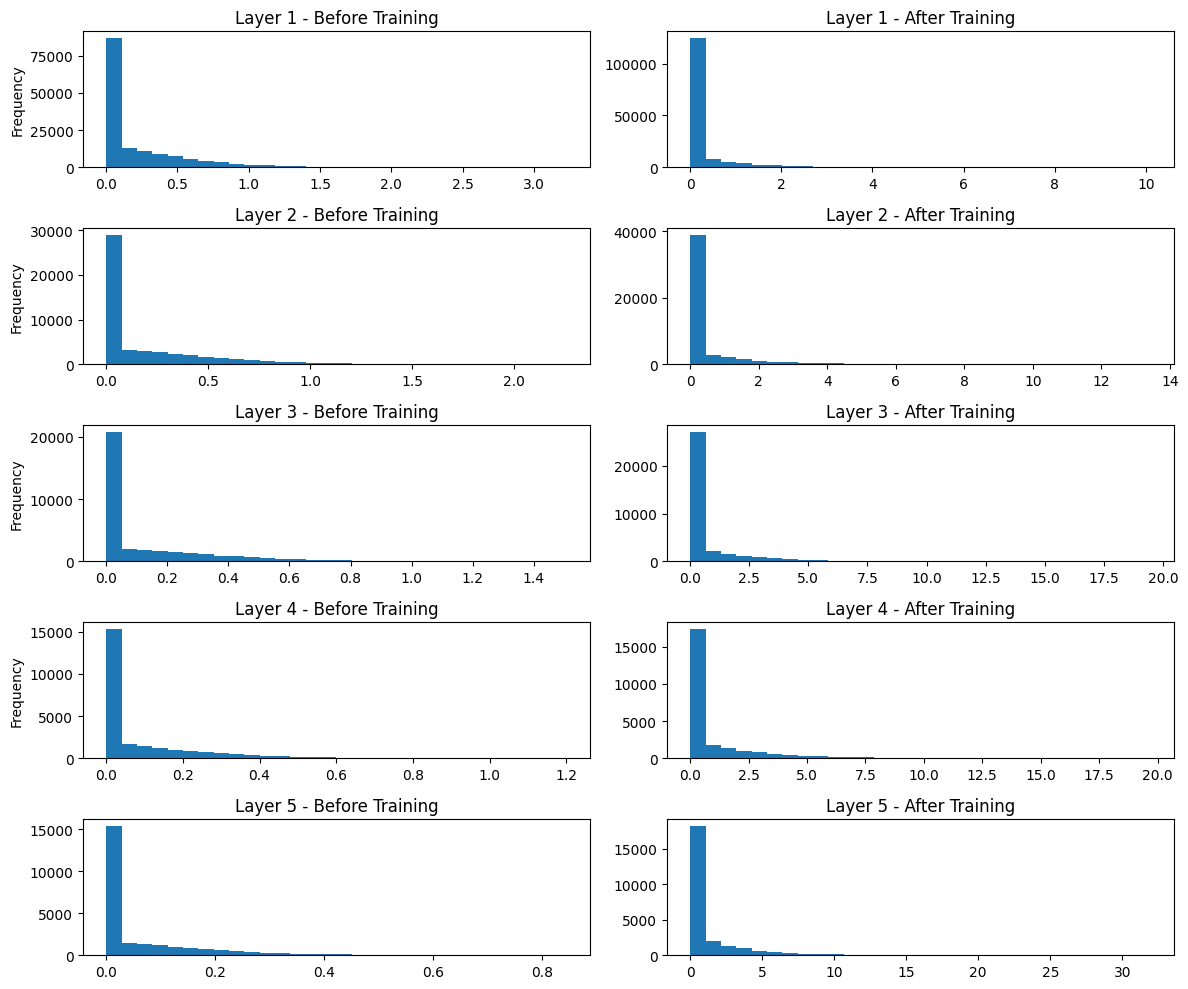

In [10]:
fig, axes = plt.subplots(5, 2, figsize=(12, 10))
for i in range(5):
    axes[i, 0].hist(peek_start[i].ravel(), bins=30)
    axes[i, 0].set_title(f"Layer {i+1} - Before Training")

    axes[i, 1].hist(plain_end[i].ravel(), bins=30)
    axes[i, 1].set_title(f"Layer {i+1} - After Training")

axes[0,0].set_ylabel("Frequency")
axes[1,0].set_ylabel("Frequency")
axes[2,0].set_ylabel("Frequency")
axes[3,0].set_ylabel("Frequency")
plt.tight_layout()
plt.show()

In [11]:
for i in range(5):
    std_start = np.std(peek_start[i])
    std_end = np.std(plain_end[i])
    diff = std_end / std_start

    print(f"Layer {i+1}: std before training = {std_start:.4f}, std after training = {std_end:.4f}, ratio = {diff:.4f}")

Layer 1: std before training = 0.3378, std after training = 0.5597, ratio = 1.6568
Layer 2: std before training = 0.2841, std after training = 1.0680, ratio = 3.7586
Layer 3: std before training = 0.1968, std after training = 1.4738, ratio = 7.4896
Layer 4: std before training = 0.1455, std after training = 2.1084, ratio = 14.4901
Layer 5: std before training = 0.1053, std after training = 2.6563, ratio = 25.2375


In [12]:
# Normalized model

norm = keras.Sequential([
    keras.Input(shape=(28 * 28,)),
    keras.layers.Dense(300),
    keras.layers.BatchNormalization(),
    keras.layers.Activation("relu", name="block1"),
    keras.layers.Dense(100),
    keras.layers.BatchNormalization(),
    keras.layers.Activation("relu", name="block2"),
    keras.layers.Dense(70),
    keras.layers.BatchNormalization(),
    keras.layers.Activation("relu", name="block3"),
    keras.layers.Dense(50),
    keras.layers.BatchNormalization(),
    keras.layers.Activation("relu", name="block4"),
    keras.layers.Dense(50),
    keras.layers.BatchNormalization(),
    keras.layers.Activation("relu", name="block5"),
    keras.layers.Dense(10, activation="softmax")
])

norm.compile(optimizer=keras.optimizers.SGD(learning_rate=0.1), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
norm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 300)            │         1,200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1 (Activation)             │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2 (Activation)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 70)             │         7,070 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 70)             │           280 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3 (Activation)             │ (None, 70)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 50)             │         3,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 50)             │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4 (Activation)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 50)             │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5 (Activation)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 281,560 (1.07 MB)

 Trainable params: 280,420 (1.07 MB)

 Non-trainable params: 1,140 (4.45 KB)

In [13]:
peek_norm = keras.Model(
    inputs=norm.inputs,
    outputs=[
        norm.get_layer("block1").output,
        norm.get_layer("block2").output,
        norm.get_layer("block3").output,
        norm.get_layer("block4").output,
        norm.get_layer("block5").output
    ]
)
peek_start = peek_norm.predict(X_train[:500], verbose=0)

In [14]:
hist_norm = norm.fit(X_train, y_train, epochs=100, verbose=0, batch_size=32)

# 6. Evaluate accuracy and loss
loss = hist_norm.history["loss"]
acc = norm.evaluate(X_test, y_test, verbose=0)[1]

print(f"\nTest accuracy: {acc * 100:.2f}%")
print(f"Final training loss: {loss[-1]:.4f}\n")


Test accuracy: 86.40%
Final training loss: 0.0185



In [15]:
peek_end = peek_norm.predict(X_test[:500], verbose=0)

In [16]:
for i in range(5):
    std_before = np.std(peek_start[i])
    std_after = np.std(peek_end[i])
    ratio = std_after / std_before
    
    print(
        f"Layer {i+1}: std before training = {std_before:.4f}, "
        f"std after training = {std_after:.4f}, ratio = {ratio:.4f}"
    )

Layer 1: std before training = 0.3141, std after training = 0.5399, ratio = 1.7187
Layer 2: std before training = 0.2632, std after training = 0.6205, ratio = 2.3573
Layer 3: std before training = 0.1954, std after training = 0.6691, ratio = 3.4243
Layer 4: std before training = 0.1259, std after training = 0.6668, ratio = 5.2953
Layer 5: std before training = 0.0712, std after training = 1.0249, ratio = 14.3949
